Number of files: 362
First file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_3yrs_100hru_100bh_test_no_downscale/postprocess/output_dir/20140101.nc
Last file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_3yrs_100hru_100bh_test_no_downscale/postprocess/output_dir/20141228.nc


KeyError: 'S'

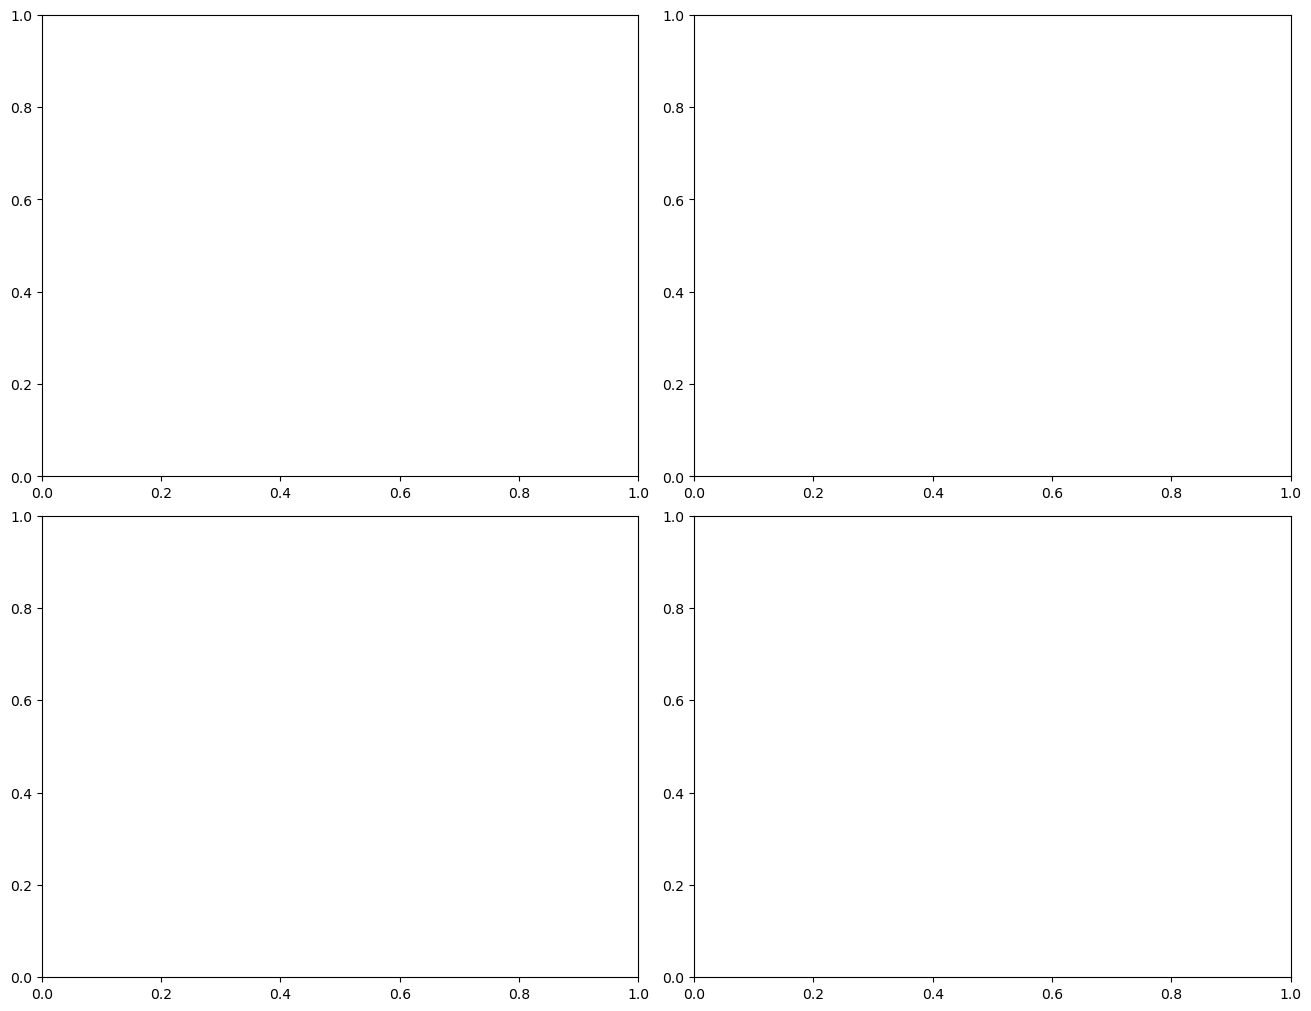

In [14]:
import os
import glob
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt

# Path

#path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_11yrs_100hru_100bh_test_new_test_domain/"
path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_3yrs_100hru_100bh_test_no_downscale/"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

output_dir = path + "postprocess/output_dir/"
files = sorted(glob.glob(output_dir + "*.nc"))

print("Number of files:", len(files))
print("First file:", files[0])
print("Last file:", files[-1])

# select variables
varname = "fsno"

#Period
year_start = 2014
year_end = 2014

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {"Winter": [12, 1, 2], "Spring": [3, 4, 5], "Summer": [6, 7, 8],"Fall": [9, 10, 11],}

# Read cordinates
with nc.Dataset(files[0]) as fp:
    lon = np.array(fp.variables["lon"][:])
    lat = np.array(fp.variables["lat"][:])

# Figure
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

axes = axes.flatten()
fig.patch.set_facecolor("white")

# loop over seasons
for ax, season in zip(axes[:1], seasons[1]):
# for ax, season in zip(axes, seasons):
    months = season_months[season]
    print(f"\nCreating plot for {season}")
    
    season_files = []
    for f in files:
        fname = os.path.basename(f).replace(".nc", "")
        date = pd.to_datetime(fname, format="%Y%m%d")

        if year_start <= date.year <= year_end and date.month in months:
            season_files.append(f)
        #if date.month in months:
         #   season_files.append(f)

    print(f"{season} files:", len(season_files))

    sum_map = None
    count_map = None

    for i, f in enumerate(season_files):

        if i % 500 == 0:
            print(f"  {season}: {i+1}/{len(season_files)} {os.path.basename(f)}")

        with nc.Dataset(f) as fp:
            data = np.array(fp.variables[varname][:], dtype=np.float32)

        data[data <= -9990] = np.nan

        # Daily mean from 8 three-hourly outputs
        if data.ndim == 3:
            data = np.nanmean(data, axis=0)

        if sum_map is None:
            sum_map = np.zeros_like(data, dtype=np.float32)
            count_map = np.zeros_like(data, dtype=np.float32)

        valid = np.isfinite(data)

        sum_map[valid] += data[valid]
        count_map[valid] += 1

    # Seasonal mean
    season_mean = np.divide(
        sum_map,
        count_map,
        out=np.full_like(sum_map, np.nan, dtype=np.float32),
        where=count_map > 0
    )

    season_mean = np.ma.masked_invalid(season_mean)

    plot_data = season_mean

    valid = np.isfinite(season_mean)
    rows, cols = np.where(valid)

    xmin = lon[cols.min()]
    xmax = lon[cols.max()]
    ymin = lat[rows.min()]
    ymax = lat[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    ax.set_facecolor("white")

    im = ax.imshow(
        plot_data,
        origin="lower",
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
        cmap="viridis",
        interpolation="nearest"
    )

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {season}", fontsize=13)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    cbar = fig.colorbar(
        im,
        ax=ax,
        label="SMC [m³/m³]",
        fraction=0.046,
        pad=0.02
    )

    cbar.outline.set_linewidth(0.8)

# Save
outfile = os.path.join(outputdir,f"2km_PP_smc_surface_seasonal_mean_postprocess_tight_{year_start}_{year_end}_dailymean.png")

plt.savefig(outfile, dpi=300, bbox_inches="tight", facecolor="white")
print("\nSaved:", outfile)

plt.show()

In [13]:
print(data.shape)

(630, 630)


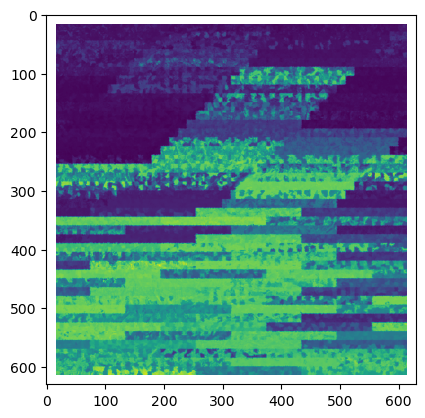

In [12]:
data_f = np.copy(data, order='C') 
plt.figure()
plt.imshow(data_f)
plt.show()

In [16]:
import xarray as xr
dstest = xr.open_dataset("/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_3yrs_100hru_100bh_test_no_downscale/postprocess/output_dir/20140101.nc")

In [22]:
import geospatialtools.gdal_tools as gdal_tools
da = rioxarray.open_rasterio("/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_3yrs_100hru_100bh_test_no_downscale/postprocess/mapping.tif")

ModuleNotFoundError: No module named 'rioxarray'

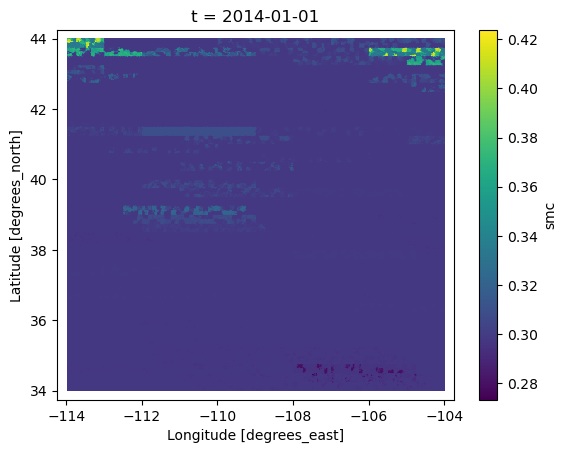

In [23]:
dstest['smc'].isel(t=0).plot()

In [1]:
from osgeo import gdal

# Open the TIF file in read-only mode
dataset = gdal.Open('/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_3yrs_100hru_100bh_test_no_downscale/postprocess/mapping.tif', gdal.GA_ReadOnly)

# Verify if the dataset opened successfully
if dataset is not None:
    print(f"File opened successfully!")
    print(f"Dimensions: {dataset.RasterXSize} x {dataset.RasterYSize}")
    print(f"Number of bands: {dataset.RasterCount}")
    
    # Read the first band as a numpy array
    band1 = dataset.GetRasterBand(1)
    array_data = band1.ReadAsArray()
    print("Band 1 as array shape:", array_data.shape)
else:
    print("Failed to open the file. Check your file path.")

File opened successfully!
Dimensions: 630 x 630
Number of bands: 1
Band 1 as array shape: (630, 630)


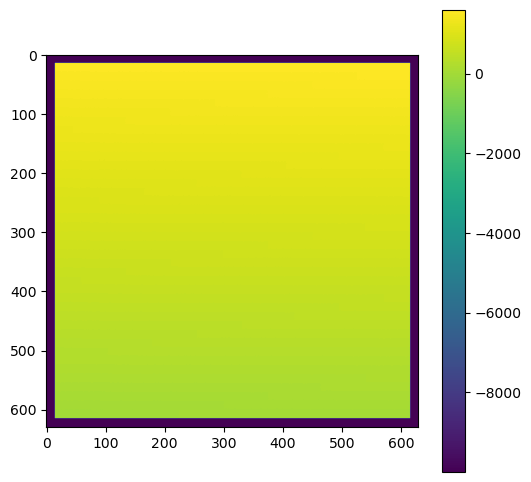

In [3]:
import numpy as np
import matplotlib.pyplot as plt
data_f = np.copy(array_data, order='C')

plt.figure(figsize=(6,6))
plt.imshow(data_f)
plt.colorbar()
plt.show()

In [5]:
import numpy as np

print(array_data.dtype)
print(np.nanmin(array_data), np.nanmax(array_data))
print(np.unique(array_data)[:20])

float64
-9999.0 1600.0
[-9.999e+03  1.000e+00  2.000e+00  3.000e+00  4.000e+00  5.000e+00
  6.000e+00  7.000e+00  8.000e+00  9.000e+00  1.000e+01  1.100e+01
  1.200e+01  1.300e+01  1.400e+01  1.500e+01  1.600e+01  1.700e+01
  1.800e+01  1.900e+01]
